# Data Processing and Comparative Analysis of Signal Infinite Cascade (SIC) for Bar & Edge Stimuli
This section outlines the workflow for generating neural responses to **Bar** and **Edge** stimuli using the **Signal Infinite Cascade (SIC)** model, and the subsequent statistical evaluation comparing its performance against the **DMN** model.

In [1]:
import sys
import os

sys.path.append(os.path.abspath('../util'))

from stimulus_Loader import StimulusProcessor
from SIC import SICModelTorch

# SIC Model Response Generation
This script facilitates the processing of visual stimuli (Bar and Edge) through the SIC (Signal Infinite Cascade) model to generate corresponding neural response data.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
import csv
import glob
import torch

# ==================================================
# Result directory (npz)
# ==================================================
RESPONSE_ROOT = "../results/Bar_edge_responses"

# ==================================================
# Global npz deduplication (scan ALL response folders)
# ==================================================
print("Scanning existing npz files for global deduplication...")
existing_npz = set()

for npz_file in glob.glob(
    os.path.join(RESPONSE_ROOT, "**", "*.npz"),
    recursive=True
):
    base = os.path.splitext(os.path.basename(npz_file))[0]
    existing_npz.add(base)

print(f"Found {len(existing_npz)} existing response files")

# ---------------------------
# Initialize StimulusProcessor
# ---------------------------
print("\nInitializing StimulusProcessor...")
stimulus_processor = StimulusProcessor(
    target_dt_ms=1.0,
    target_size=(41, 82),
    is_visual=False,
    fps=1000.00
)

# ---------------------------
# Load stimulus npz (Bar + Edge)
# ---------------------------
video_paths = [
    "../stimulus/Bar",
    "../stimulus/Edge"
]

video_files = []
for path in video_paths:
    files = glob.glob(os.path.join(path, "**", "*.npz"), recursive=True)
    video_files.extend(files)

if not video_files:
    raise RuntimeError("❌ No stimulus .npz files found in Bar or Edge.")

video_files = sorted(video_files)
print(f"Found {len(video_files)} stimulus files (Bar + Edge)")

stimulus_dataset = {}
skipped = 0

print("\nLoading stimuli (global dedup)...")
for v_file in tqdm(video_files, desc="Loading stimuli", unit="stim"):

    stim_base = os.path.splitext(os.path.basename(v_file))[0]

    # Get stimulus type (Bar / Edge)
    path_parts = os.path.normpath(v_file).split(os.sep)
    if "Bar" in path_parts:
        stim_type = "Bar"
    elif "Edge" in path_parts:
        stim_type = "Edge"
    else:
        stim_type = "Unknown"

    stim_name = f"{stim_base}_{stim_type}"

    # Global deduplication
    if stim_name in existing_npz:
        skipped += 1
        continue

    stimulus, _ = stimulus_processor.process_npz(
        v_file,
        verbose=False
    )

    stimulus_dataset[stim_name] = stimulus

print(f"✅ Stimuli loaded: {len(stimulus_dataset)}")
print(f"⏭️  Stimuli skipped (existing npz anywhere): {skipped}")


# Initialize SIC model
SIC_model = SICModelTorch(
    matrix_dir="neuron_matrices",
    output_dir="../results/responses/fri",
    t_step=10,
    rate=100,
    device=torch.device("cuda:0")
)

def read_all_neuron_ids(filename='../data/classification.txt'):
    neuron_ids = []
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                if 'root_id' in row and row['root_id'].strip():
                    try:
                        neuron_ids.append(int(row['root_id'].strip()))
                    except ValueError:
                        continue
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
    except Exception as e:
        print(f"Error reading file: {str(e)}")
    return neuron_ids

neuron_ids = read_all_neuron_ids()
print(f"Found {len(neuron_ids)} neurons")

weights = SIC_model.load_weights(neuron_ids, center_to_origin=True)
print("Weights loaded successfully")

print("Calculating SIC responses...")
for stim_name, stimulus in tqdm(
    stimulus_dataset.items(),
    desc="Processing stimuli",
    unit="stimulus"
):
    SIC_model.calculate_response_baseline(
        stimulus,
        weights,
        responce_threshold=0,
        baseline_steps=50,
        stim_name=stim_name
    )

print("\n" + "="*50)
print("PREPROCESSING COMPLETE")
print("="*50)
print(f"Total stimuli processed: {len(stimulus_dataset)}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*50)

Scanning existing npz files for global deduplication...
Found 0 existing response files

Initializing StimulusProcessor...
Found 16 stimulus files (Bar + Edge)

Loading stimuli (global dedup)...


Loading stimuli: 100%|██████████| 16/16 [00:01<00:00, 10.66stim/s]


✅ Stimuli loaded: 16
⏭️  Stimuli skipped (existing npz anywhere): 0
Using device: cuda:0
Found 139255 neurons
Weights loaded successfully
Calculating SIC responses...


Processing stimuli: 100%|██████████| 16/16 [13:20<00:00, 50.04s/stimulus]


PREPROCESSING COMPLETE
Total stimuli processed: 16
Timestamp: 2026-03-11 23:42:13


# Plot Style Configuration

In [1]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'nature', 'no-latex'])

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],  # Ubuntu 推荐
    "font.size": 16,
    "axes.labelsize": 16,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.5,
})

# Population Response Visualization
This script extracts and visualizes population-level neural responses for specific cell types. It processes simulation data to generate plots showing individual neuron traces, the population mean, and the Standard Error of the Mean (SEM).

In [ ]:
import os
import glob
import gc
import csv
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# Target Configuration (Modify here: e.g., "Tm3", "Mi1")
# =====================================================
target_name = "T2"

# =====================================================
# Directories (Output folder updates with target_name)
# =====================================================
responses_dir = "../results/responses/fri/202603"
output_dir = f"../results/{target_name}_population"

os.makedirs(output_dir, exist_ok=True)

# =====================================================
# Read neuron IDs
# =====================================================
def read_neuron_ids(neuron_type, side=None, filename='../data/visual_neuron_types.txt'):
    neuron_ids = []

    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f, delimiter=',')

            for row in reader:
                if row['type'] == neuron_type and (
                    side is None or row['side'].lower() == side.lower()
                ):
                    try:
                        neuron_ids.append(int(row['root_id']))
                    except ValueError:
                        continue

    except Exception as e:
        print(f"Error reading file: {str(e)}")

    return neuron_ids

# =====================================================
# Retrieve target neurons
# =====================================================
show_ids = read_neuron_ids(target_name, side=None)
show_ids = set(map(str, show_ids))

print(f"Total {target_name} neurons: {len(show_ids)}")

# =====================================================
# Locate specific npz files (Filter by target name)
# =====================================================
search_pattern = os.path.join(responses_dir, f"*{target_name}*.npz")
npz_files = sorted(glob.glob(search_pattern))

print(f"Total npz files matching '{target_name}': {len(npz_files)}")

# =====================================================
# Main Processing Loop
# =====================================================
for npz_path in tqdm(npz_files):

    data = np.load(npz_path, allow_pickle=True)

    if "neuron_ids" not in data or "responses" not in data:
        continue

    neuron_ids = data["neuron_ids"].astype(str)
    responses = data["responses"]

    # -------------------------------------------------
    # Filter responses for target neurons only 
    # -------------------------------------------------
    selected = []

    for nid, resp in zip(neuron_ids, responses):
        if nid in show_ids:
            selected.append(resp)

    if len(selected) == 0:
        continue

    selected = np.array(selected)

    # -------------------------------------------------
    # Calculate statistics
    # -------------------------------------------------
    mean_resp = np.mean(selected, axis=0)
    sem_resp = np.std(selected, axis=0) / np.sqrt(selected.shape[0])

    # -------------------------------------------------
    # Plotting
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=(4, 2))

    # Individual neuron traces
    for resp in selected:
        ax.plot(
            resp,
            color="gray",
            alpha=0.1,
            linewidth=0.5
        )

    # SEM
    x = np.arange(len(mean_resp))

    ax.fill_between(
        x,
        mean_resp - sem_resp,
        mean_resp + sem_resp,
        color="gray",
        alpha=0.4
    )

    # Mean
    ax.plot(
        mean_resp,
        color="black",
        linewidth=2,
        alpha=1
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_xlim(0, len(mean_resp) - 1)

    # Save output (Filename includes target name)
    fname = os.path.basename(npz_path).replace(".npz", f"_{target_name}_population.png")

    fig.savefig(
        os.path.join(output_dir, fname),
        dpi=600,
        bbox_inches="tight"
    )

    plt.close(fig)

    gc.collect()

print("\n✅ All plots finished.")

Total T2 neurons: 1466
Total npz files matching 'T2': 2


100%|██████████| 2/2 [00:04<00:00,  2.45s/it]


✅ All plots finished.


# Signal Infinite Cascade (SIC) Response Extraction
This script extracts population-level neural responses generated by the Signal Infinite Cascade (SIC) model. It processes simulation results, performs normalization, and exports the data into structured CSV files for analysis.

In [2]:
import os
import csv
import numpy as np
import pandas as pd
from tqdm import tqdm

# Specify GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# =====================================================
# Parameter Settings
# =====================================================
target_name = "CT1"          # 目标神经元名称
drop_steps = 0              # 需要去掉的前 N 个步长
time_per_step = 0.01         # 每一个步长代表的时间间隔 (秒)

# Input file path
npz_path = "/home/jzyh/xjp_projects/SIC/results/responses/move/bar_down_dark_Bar.npz"

# Output directory
output_dir = f"../results/others/SIC_value/{target_name}_move_exports"
os.makedirs(output_dir, exist_ok=True)

# =====================================================
# Read neuron IDs
# =====================================================
def read_neuron_ids(neuron_type, side=None, filename='../data/visual_neuron_types.txt'):
    neuron_ids = []
    try:
        with open(filename, 'r') as f:
            reader = csv.DictReader(f, delimiter=',')
            for row in reader:
                if row['type'] == neuron_type and (side is None or row['side'].lower() == side.lower()):
                    try:
                        neuron_ids.append(int(row['root_id']))
                    except ValueError:
                        continue
    except Exception as e:
        print(f"Error reading file: {str(e)}")
    return neuron_ids

show_ids = set(map(str, read_neuron_ids(target_name, side=None)))
print(f"Total {target_name} neurons identified: {len(show_ids)}")

# =====================================================
# Extraction, Processing, and CSV Export
# =====================================================
if not os.path.exists(npz_path):
    print(f"Error: File not found {npz_path}")
else:
    try:
        data = np.load(npz_path, allow_pickle=True)
        
        if "neuron_ids" not in data or "responses" not in data:
            print("Invalid file format: Missing required keys.")
        else:
            neuron_ids = data["neuron_ids"].astype(str)
            responses = data["responses"]

            # 1. Filter responses for the target neuron type
            selected = [resp for nid, resp in zip(neuron_ids, responses) if nid in show_ids]
            
            if len(selected) == 0:
                print(f"No response data found for {target_name} in this file.")
            else:
                selected = np.array(selected)
                
                # 2. Calculate population mean response
                mean_resp = np.mean(selected, axis=0)

                # 3. Trim initial steps
                if len(mean_resp) <= drop_steps:
                    print(f"Data length insufficient to drop {drop_steps} steps.")
                else:
                    trimmed_resp = mean_resp[drop_steps:]

                    # 4. Normalize to [0, 1]
                    r_min = trimmed_resp.min()
                    r_max = trimmed_resp.max()
                    if r_max > r_min:
                        norm_resp = (trimmed_resp - r_min) / (r_max - r_min)
                    else:
                        norm_resp = np.zeros_like(trimmed_resp)

                    # 5. Generate time series
                    timestamps = np.arange(len(norm_resp)) * time_per_step

                    # 6. Construct DataFrame
                    df = pd.DataFrame({
                        'Time (s)': timestamps,
                        'SIC_Value': norm_resp  # SIC_Value represents the predicted response
                    })
                    
                    # Round to two decimal places for clarity
                    df = df.round(2)

                    # 7. Generate output filename (e.g., CT1-down_dark_Bar.csv)
                    
                    fname = f"{target_name}-down_dark_Bar.csv"
                    csv_path = os.path.join(output_dir, fname)
                    
                    df.to_csv(csv_path, index=False)
                    print(f"\n✅ Extraction successful! CSV saved to: {csv_path}")

    except Exception as e:
        print(f"Error during processing: {e}")

print("\nProcessing complete.")

Total CT1 neurons identified: 2

✅ Extraction successful! CSV saved to: ../results/others/SIC_value/CT1_move_exports/CT1-down_dark_Bar.csv

Processing complete.


# SIC Model Correlation & Alignment Analysis(Single File)
This script evaluates the Signal Infinite Cascade (SIC) model by performing a two-stage statistical validation. It first conducts a cross-correlation analysis to identify **the optimal temporal lag** between experimental data and model predictions, then calculates **the Pearson correlation coefficient ($r$)** and **Mean Squared Error (MSE)** on the synchronized datasets.

In [1]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import os

# Specify GPU device
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# 1. File Path Configuration
file_path = "/home/jzyh/xjp_projects/SIC/results/calculate/Mi4_csv_exports/Fig3A(Mi4-Off)_extracted.csv"

try:
    df = pd.read_csv(file_path)
    df['Exp_Value'] = pd.to_numeric(df['Exp_Value'], errors='coerce')
    df['SIC_Value'] = pd.to_numeric(df['SIC_Value'], errors='coerce')
    df = df.dropna(subset=['Exp_Value', 'SIC_Value'])

    X = df['Exp_Value'].values
    Y = df['SIC_Value'].values

    # 2. Cross-correlation analysis to identify the optimal temporal lag
    X_centered = X - np.mean(X)
    Y_centered = Y - np.mean(Y)
    corr = np.correlate(X_centered, Y_centered, mode='full')
    lags = np.arange(-len(Y) + 1, len(X))
    max_corr_index = np.argmax(corr)
    best_lag = lags[max_corr_index]

    # 3. Synchronize data based on the identified best lag
    if best_lag > 0:
        aligned_exp = X[best_lag:]
        aligned_sic = Y[:len(Y)-best_lag]
    elif best_lag < 0:
        aligned_exp = X[:len(X)+best_lag]
        aligned_sic = Y[-best_lag:]
    else:
        aligned_exp = X
        aligned_sic = Y

    # 4. Statistical validation on aligned datasets
    # Calculate Pearson correlation coefficient and p-value
    r, p_value = stats.pearsonr(aligned_exp, aligned_sic)
    # Calculate Mean Squared Error (MSE) to assess model fit
    mse = np.mean((aligned_sic - aligned_exp) ** 2)

    # 5. Output Results
    print("="*40)
    print(f"Analysis Results (Post-Alignment): {os.path.basename(file_path)}")
    print("="*40)
    print(f"Best Lag:            {best_lag}")
    print(f"Pearson r:           {r:.4f}")
    print(f"P-value:             {p_value:.4e}")
    print(f"MSE:                 {mse:.4f}")
    print("="*40)

except Exception as e:
    print(f"An error occurred during calculation: {e}")

Analysis Results (Post-Alignment): Fig3A(Mi4-Off)_extracted.csv
Best Lag:            38
Pearson r:           0.9295
P-value:             0.0000e+00
MSE:                 0.0667


# Signal Infinite Cascade (SIC) Batch Evaluation & Metrics Comparison (All Files)
This script performs a large-scale statistical evaluation by batch-processing all compatible CSV files within a directory. It compares the Signal Infinite Cascade (SIC) model and the DMN model against experimental data. Similar to the single-file version, it first performs a cross-correlation to find the optimal temporal alignment and then calculates **Pearson’s r**, **Mean Squared Error (MSE)**, and **Dynamic Time Warping (DTW)** distances for a comprehensive performance summary.

In [2]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import os
from tqdm import tqdm
try:
    from dtaidistance import dtw
except ImportError:
    print("⚠️ 请先安装 dtaidistance: pip install dtaidistance")
    dtw = None

# =====================================================
# Path Configuration
# =====================================================
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # GPU（可选）
base_dir = "/home/jzyh/xjp_projects/SIC/results/calculate"
output_file = "/home/jzyh/xjp_projects/SIC/refer/evaluation_metrics.csv"

results_dict = {}
target_headers = {'Time (s)', 'Mask', 'Exp_Value', 'SIC_Value', 'DMN_Value'}

# =====================================================
# Metric Calculation: Alignment, Pearson r, MSE, and DTW
# =====================================================
def get_aligned_metrics(target_array, exp_array):
    # Ensure 1D arrays
    target_array = np.asarray(target_array, dtype=float).flatten()
    exp_array = np.asarray(exp_array, dtype=float).flatten()

    if len(target_array) < 2 or len(exp_array) < 2:
        return None, None, None, None

    # Find best lag using cross-correlation
    t_centered = target_array - np.mean(target_array)
    e_centered = exp_array - np.mean(exp_array)
    corr = np.correlate(e_centered, t_centered, mode='full')
    lags = np.arange(-len(t_centered) + 1, len(e_centered))
    best_lag = lags[np.argmax(corr)]

    # Align data based on best lag
    if best_lag > 0:
        a_exp = exp_array[best_lag:]
        a_target = target_array[:len(target_array)-best_lag]
    elif best_lag < 0:
        a_exp = exp_array[:len(exp_array)+best_lag]
        a_target = target_array[-best_lag:]
    else:
        a_exp = exp_array
        a_target = target_array

    if len(a_exp) < 2:
        return best_lag, None, None, None

    # Calculate Pearson r and MSE
    r, _ = stats.pearsonr(a_exp, a_target)
    mse = np.mean((a_target - a_exp) ** 2)

    # Calculate Normalized DTW distance (Distance/Length)
    dtw_score = None
    if dtw is not None:
        dtw_score = dtw.distance(a_exp, a_target) / len(a_exp)

    return best_lag, r, mse, dtw_score

# =====================================================
# Batch CSV Processing
# =====================================================
print(f"Scanning directory: {base_dir} ...")

for root, dirs, files in os.walk(base_dir):
    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)

        try:
            # Validate headers before full read
            df_head = pd.read_csv(file_path, nrows=0)
            actual_headers = set(df_head.columns.str.strip())

            if not target_headers.issubset(actual_headers):
                continue

            # Load full dataset
            df = pd.read_csv(file_path)

            # Convert to numeric types
            for col in ['Exp_Value', 'SIC_Value', 'DMN_Value']:
                df[col] = pd.to_numeric(df[col], errors='coerce')

            # Drop missing values for specific comparisons
            df_sic = df.dropna(subset=['Exp_Value', 'SIC_Value'])
            df_dmn = df.dropna(subset=['Exp_Value', 'DMN_Value'])

            # --- SIC vs Exp ---
            if len(df_sic) >= 2 and np.std(df_sic['Exp_Value']) > 0:
                sic_lag, sic_r, sic_mse, sic_dtw = get_aligned_metrics(
                    df_sic['Exp_Value'].values, df_sic['SIC_Value'].values
                )
            else:
                sic_lag, sic_r, sic_mse, sic_dtw = None, None, None, None

            # --- SIC vs Exp ---
            if len(df_sic) >= 2 and np.std(df_sic['Exp_Value']) > 0:
                sic_lag, sic_cc, sic_mse, sic_dtw = get_aligned_metrics(
                    df_sic['Exp_Value'].values, df_sic['SIC_Value'].values
                )
            else:
                sic_lag, sic_cc, sic_mse, sic_dtw = None, None, None, None

            # --- DMN vs Exp ---
            if len(df_dmn) >= 2 and np.std(df_dmn['Exp_Value']) > 0:
                dmn_lag, dmn_cc, dmn_mse, dmn_dtw = get_aligned_metrics(
                    df_dmn['Exp_Value'].values, df_dmn['DMN_Value'].values
                )
            else:
                dmn_lag, dmn_cc, dmn_mse, dmn_dtw = None, None, None, None

            # Summarize results into dictionary
            label = file.replace("_extracted.csv", "").replace(".csv", "")
            results_dict[label] = {
                "SIC_Best Lag": sic_lag,
                "SIC_Cross Corr": sic_cc,   
                "SIC_MSE": sic_mse,
                "SIC_DTW": sic_dtw,
                "DMN_Best Lag": dmn_lag,
                "DMN_Cross Corr": dmn_cc,  
                "DMN_MSE": dmn_mse,
                "DMN_DTW": dmn_dtw
            }

            print(f"Successfully processed:{label}")

        except Exception as e:
            print(f"Skipping file {file} due to error: {e}")

# =====================================================
# Export Consolidated Metrics
# =====================================================
if results_dict:
    results_df = pd.DataFrame(results_dict)
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    results_df.to_csv(output_file, float_format="%.4f")
    print("\n" + "="*40)
    print(f"✅ Batch processing complete! Results saved to: {output_file}")
    print("="*40)
else:
    print("❌ No files matching the header requirements were found.")

Scanning directory: /home/jzyh/xjp_projects/SIC/results/calculate ...
Successfully processed:Fig4a(T3-both)
Successfully processed:Fig4a(T2-both)
Successfully processed:Fig3A(Mi4-Off)
Successfully processed:Fig3A(Mi4-On)
Successfully processed:Fig3c(Tm9-Off)Direct
Successfully processed:Fig4b(Tm3-off)
Successfully processed:Fig2A(Tm3-On-3)
Successfully processed:Fig2A(Tm3-On-1)
Successfully processed:Fig3A(Tm3-Off)
Successfully processed:Fig3A(Tm3-On)
Successfully processed:Fig2A(Tm3-On-2)
Successfully processed:Fig3A(C3-On)
Successfully processed:Fig3A(C3-Off)
Successfully processed:Fig2B(Tm1-Off-3)
Successfully processed:Fig2B(Tm1-Off-2)
Successfully processed:Fig2B(Tm1-Off-1)
Successfully processed:Fig4b(Tm1-off)
Successfully processed:Fig2A(Mi1-On-1)
Successfully processed:Fig2A(Mi1-On-2)
Successfully processed:Fig3A(Mi1-On)
Successfully processed:Fig3A(Mi1-Off)
Successfully processed:Fig2A(Mi1-On-3)
Successfully processed:Fig3b(Mi1-on)
Successfully processed:Fig2B(Tm2-Off-1)
Succe

# SIC vs. DMN Model Performance Visualization
This script generates high-quality comparative plots to visualize the performance metrics of the **Signal Infinite Cascade (SIC)** model against the **DMN model**. It reads the consolidated metrics from a CSV file and produces a four-panel figure (Best Lag, Cross-Correlation, MSE, and DTW) using professional scientific plotting styles.

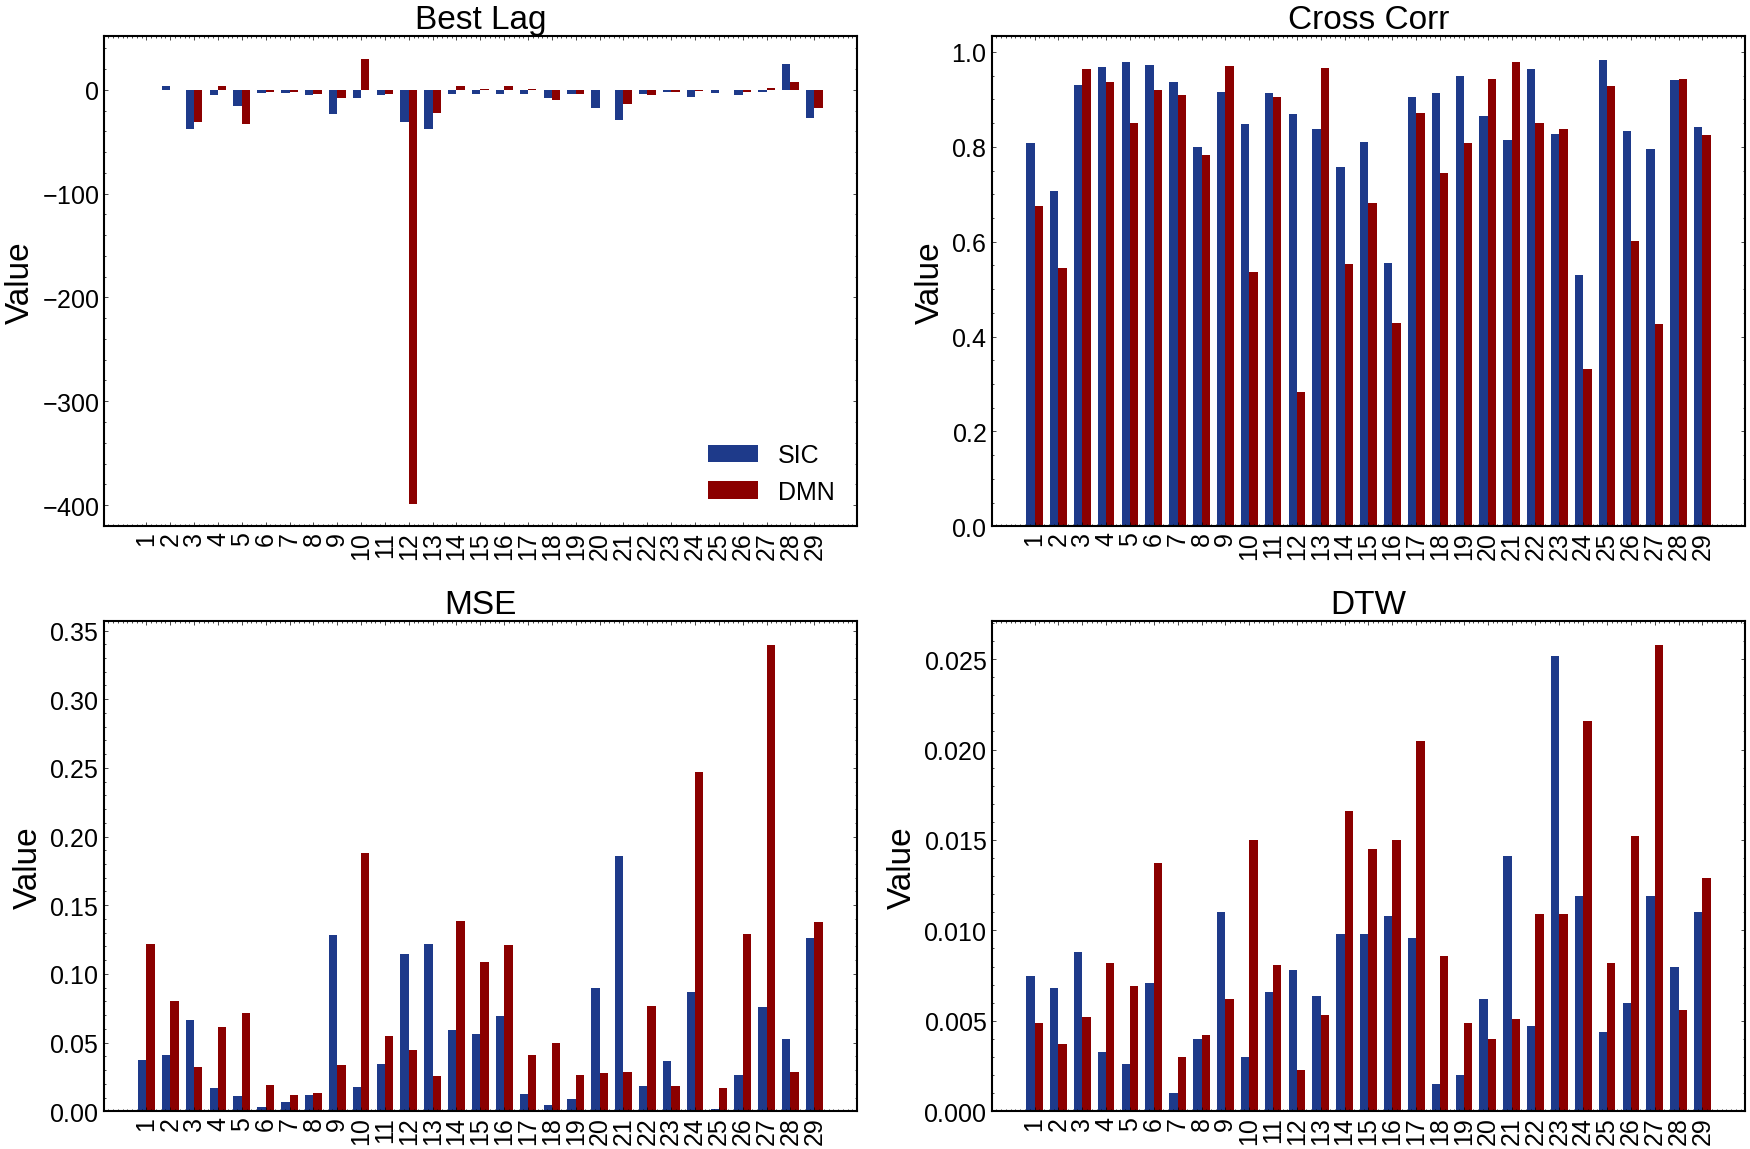

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# ==================== Style Configuration ====================
plt.style.use(['science', 'nature', 'no-latex'])
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "font.size": 20,
    "axes.labelsize": 24,
    "axes.titlesize": 24,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.linewidth": 1.5,
})

# ==================== Data Loading ====================
file_path = "../refer/evaluation_metrics.csv"
df_raw = pd.read_csv(file_path)
df_raw.rename(columns={df_raw.columns[0]: "Metric"}, inplace=True)

# Separate SIC (Signal Infinite Cascade) and DMN data
sic_mask = df_raw["Metric"].str.startswith("SIC")
dmn_mask = df_raw["Metric"].str.startswith("DMN")

sic_values = df_raw[sic_mask].iloc[:, 1:].astype(float).values
dmn_values = df_raw[dmn_mask].iloc[:, 1:].astype(float).values

sic_metrics = [m.replace("SIC_", "") for m in df_raw[sic_mask]["Metric"].tolist()]

# Number of samples/models
n_models = sic_values.shape[1]

# Color Palette
deep_blue = '#1E3A8A'   # SIC
deep_red = '#8B0000'    # DMN

# ==================== Plotting Function ====================
def plot_metric_subplot(ax, metric_idx, metric_name, sic_vals, dmn_vals):
    x = np.arange(1, sic_vals.shape[1]+1)  # Index 1, 2, 3...
    width = 0.35

    sic_data = sic_vals[metric_idx, :]
    dmn_data = dmn_vals[metric_idx, :]

    ax.bar(x - width/2, sic_data, width, label="SIC", color=deep_blue)
    ax.bar(x + width/2, dmn_data, width, label="DMN", color=deep_red)

    # Set x-axis labels and rotate 90 degrees
    ax.set_xticks(x)
    ax.set_xticklabels(x, rotation=90)
    ax.set_ylabel("Value")
    ax.set_title(metric_name)

# ==================== Create 4-Panel Figure ====================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Iterate through each metric to create subplots
for i, metric in enumerate(sic_metrics):
    plot_metric_subplot(axes[i], i, metric, sic_values, dmn_values)


axes[0].legend(loc='lower right')

plt.tight_layout()
plt.show()

# SIC vs. DMN Statistical Comparison & Metric Visualization
This script generates a comparative statistical analysis of the **Signal Infinite Cascade (SIC)** model and the **DMN** model. It summarizes the performance across all samples by calculating the mean and standard deviation for key metrics, identifying the statistically "superior" model for each category with visual markers.

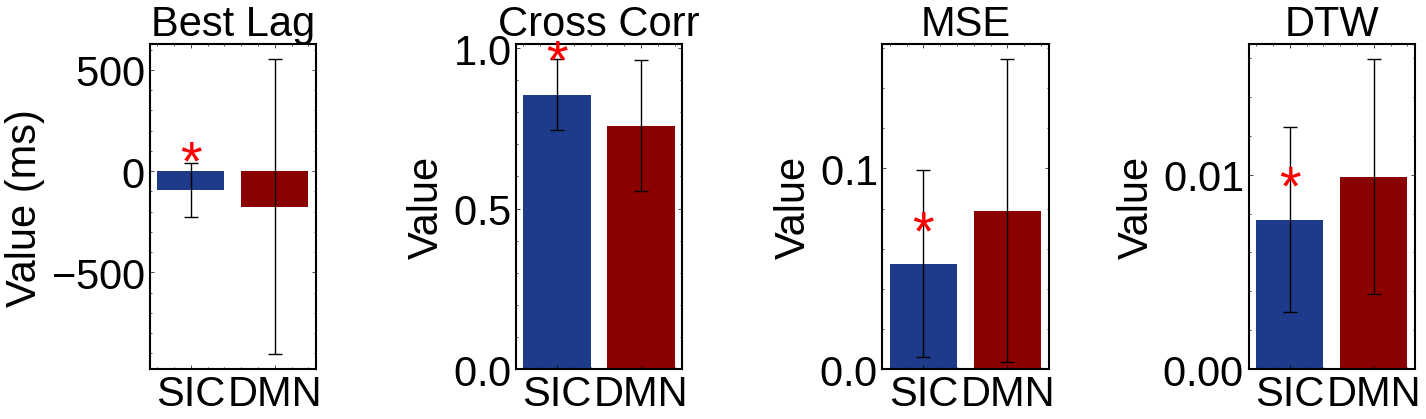

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# ==================== Style Configuration ====================
plt.style.use(['science', 'nature', 'no-latex'])
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "font.size": 30,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "legend.fontsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "axes.linewidth": 1.5,
})

# ==================== Data Loading ====================
file_path = "../refer/evaluation_metrics.csv"
df_raw = pd.read_csv(file_path)
df_raw.rename(columns={df_raw.columns[0]: "Metric"}, inplace=True)

# Separate SIC (Signal Infinite Cascade) and DMN data groups
sic_mask = df_raw["Metric"].str.startswith("SIC")
dmn_mask = df_raw["Metric"].str.startswith("DMN")

sic_values = df_raw[sic_mask].iloc[:, 1:].astype(float).values
dmn_values = df_raw[dmn_mask].iloc[:, 1:].astype(float).values

sic_metrics = [m.replace("SIC_", "") for m in df_raw[sic_mask]["Metric"].tolist()]

# Color Palette
deep_blue = '#1E3A8A'   # SIC
deep_red = '#8B0000'    # DMN

# ==================== Plotting Function ====================
def plot_metric_subplot(ax, metric_idx, metric_name, sic_vals, dmn_vals):
    # Calculate Mean and Standard Deviation
    sic_data = sic_vals[metric_idx, :].copy()
    dmn_data = dmn_vals[metric_idx, :].copy()

    # Convert "Best Lag" units to ms if applicable
    if metric_name == "Best Lag":
        sic_data *= 10
        dmn_data *= 10

    sic_mean = np.nanmean(sic_data)
    sic_std = np.nanstd(sic_data)
    dmn_mean = np.nanmean(dmn_data)
    dmn_std = np.nanstd(dmn_data)

    x = np.arange(2)  # 0 = SIC, 1 = DMN
    means = [sic_mean, dmn_mean]
    errors = [sic_std, dmn_std]
    labels = ["SIC", "DMN"]
    colors = [deep_blue, deep_red]

    # Plot bars with error bars
    bars = ax.bar(x, means, yerr=errors, capsize=5, color=colors)

    # Logic to identify the "Best" performing model
    if metric_name == "Best Lag":
        best_idx = np.argmin([abs(sic_mean), abs(dmn_mean)])
    elif metric_name == "Cross Corr":
        best_idx = np.argmax([sic_mean, dmn_mean])
    else:  # MSE / DTW
        best_idx = np.argmin([sic_mean, dmn_mean])

    # Annotate the superior model with an asterisk
    ax.text(x[best_idx], means[best_idx] + 0.02*np.max(means), "*", 
            ha='center', va='bottom', fontsize=40, color='red')

    # Axis and Title formatting
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Value" + (" (ms)" if metric_name == "Best Lag" else ""))
    ax.set_title(metric_name)

# ==================== Create 4-Panel Summary Figure ====================
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes = axes.flatten()

for i, metric in enumerate(sic_metrics):
    plot_metric_subplot(axes[i], i, metric, sic_values, dmn_values)

plt.tight_layout()
plt.show()